# En la siguiente celda se hicieron cambios al codigo original porque segun lo que investigue la libreria yahoo_finance ya quedo obsoleta desde 2017 y se usa una nueva libreria llamada yfinance:

In [10]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

In [7]:
msoft = yf.Ticker("MSFT")
info = msoft.info

print("Open:      ", info.get("open"))
print("Price:     ", info.get("currentPrice"))
print("Last trade:", info.get("regularMarketTime"))

Open:       405.84
Price:      404.88
Last trade: 1773259202


In [25]:
def get_prices(share_symbol, start_date, end_date, cache_filename):
    try:
        stock_prices = np.load(cache_filename, allow_pickle=True)
    except IOError:
        ticker = yf.Ticker(share_symbol)
        stock_hist = ticker.history(start=start_date, end=end_date)
        stock_prices = stock_hist['Open'].tolist()
        np.save(cache_filename, stock_prices)
    return stock_prices

In [26]:
def plot_prices(prices):
    plt.title('Opening stock prices')
    plt.xlabel('day')
    plt.ylabel('price ($)')
    plt.plot(prices)
    plt.savefig('prices.png')

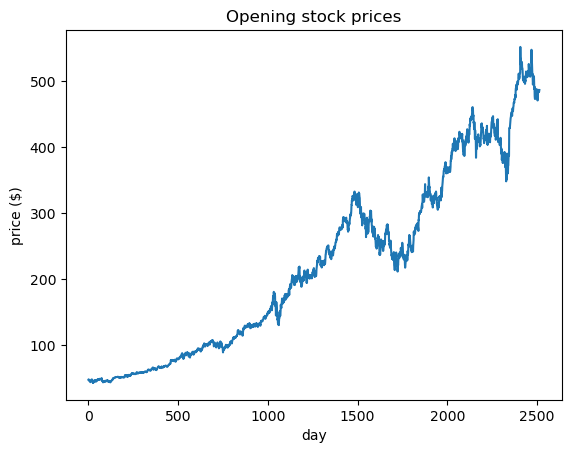

In [27]:
if __name__ == '__main__':
    prices = get_prices('MSFT', '2016-01-01', '2026-01-01', 'historical_stock_prices.npy') # <----- Se uso una fecha mas reciente #
    plot_prices(prices)